# Drude weight and the optical f-sum rule
Let us see where the optical weight of a chain goes when it becomes an insulator, with
`h.get_drude_weight()` and `h.get_sum_rule_weight()`. In a metal part of the response to an
electric field is the free acceleration of the electrons at the Fermi surface, which in
$\mathrm{Re}\,\sigma_{xx}(\omega)$ is a peak at zero frequency whose weight is the Drude weight
$D$; in an insulator there is no Fermi surface and the whole weight sits in the interband
absorption above the gap. The total does not depend on how it is split: it is fixed by the
optical f-sum rule,
$$
\int \mathrm{Re}\,\sigma_{aa}(\omega)\,d\omega = \pi W_{aa}
$$
where $W$ is the diamagnetic weight, an expectation value in the ground state that
`h.get_sum_rule_weight()` returns. Both $D$ and $W$ are $3\times3$ tensors, in the same units
as `h.get_optical_conductivity()`.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula.multihopping import MultiHopping

### A chain that dimerizes
We take a chain with alternating hoppings $1+d$ and $1-d$ in a two-site unit cell, the Peierls
distortion. At $d=0$ the chain is a metal at half filling; any $d>0$ opens a gap of $4d$ at the
Fermi energy and turns it into an insulator. The map shows $\mathrm{Re}\,\sigma_{xx}(\omega)$ as
a function of $d$.

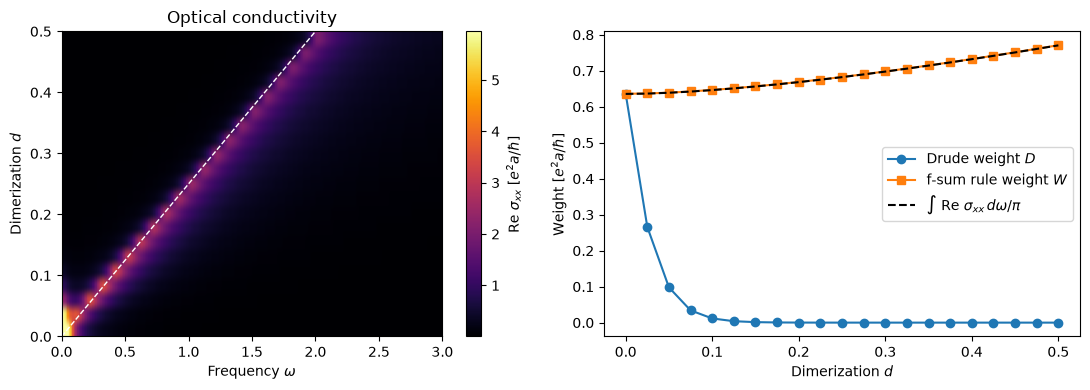

In [2]:
def dimerized_chain(d):
    """Chain with alternating hoppings 1+d and 1-d, in a two-site cell"""
    g = geometry.chain().get_supercell(2) # two sites per unit cell
    h = g.get_hamiltonian(has_spin=False) # spinless Hamiltonian
    dd = h.get_multihopping().get_dict() # real-space hoppings
    for key in dd: # intracell bond gets 1+d, intercell bond 1-d
        dd[key] = dd[key]*((1.+d) if tuple(key)==(0,0,0) else (1.-d))
    h.set_multihopping(MultiHopping(dd))
    return h

ds = np.linspace(0.,0.5,21) # dimerizations
ws = np.linspace(0.,3.,150) # frequencies
wide = np.linspace(-60.,60.,6001) # wide window for the f-sum rule
sxx,D,W,I = [],[],[],[] # storage
for d in ds:
    h = dimerized_chain(d)
    (w,s) = h.get_optical_conductivity(energies=ws,nk=400,T=0.05,delta=0.05)
    sxx.append(s[:,0,0].real) # optical conductivity
    D.append(h.get_drude_weight(nk=400,T=0.05)[0,0]) # Drude weight
    W.append(h.get_sum_rule_weight(nk=400,T=0.05)[0,0]) # f-sum rule weight
    sw = h.get_optical_conductivity(energies=wide,nk=400,T=0.05,delta=0.05)[1]
    I.append(np.trapezoid(sw[:,0,0].real,wide)/np.pi) # integrated weight

fig,axs = plt.subplots(1,2,figsize=(11,4))
im = axs[0].imshow(np.array(sxx),origin="lower",aspect="auto",cmap="inferno",
                   extent=[ws[0],ws[-1],ds[0],ds[-1]],vmax=np.max(sxx[-1])*3)
fig.colorbar(im,ax=axs[0],label=r"Re $\sigma_{xx}$ [$e^2 a/\hbar$]")
axs[0].plot(4*ds,ds,c="white",ls="--",lw=1) # the gap, 4d
axs[0].set_xlabel(r"Frequency $\omega$") ; axs[0].set_ylabel("Dimerization $d$")
axs[0].set_title("Optical conductivity")
axs[1].plot(ds,D,marker="o",label="Drude weight $D$")
axs[1].plot(ds,W,marker="s",label="f-sum rule weight $W$")
axs[1].plot(ds,I,ls="--",c="black",label=r"$\int$ Re $\sigma_{xx}\,d\omega/\pi$")
axs[1].set_xlabel("Dimerization $d$") ; axs[1].set_ylabel(r"Weight [$e^2 a/\hbar$]")
axs[1].legend()
plt.tight_layout()
plt.show()

At $d=0$ all the weight is in the Drude peak at zero frequency, since a single band has no
interband transitions. As soon as the chain dimerizes the peak loses weight and an absorption
edge appears at the gap, $\omega=4d$, the dashed line. The right panel says the same with
numbers: the Drude weight drops to zero once the gap is larger than the temperature, while the
integral of $\mathrm{Re}\,\sigma_{xx}$ over all frequencies stays equal to $\pi W$ at every
$d$, so the weight lost by the Drude peak is exactly the weight gained by the interband
absorption.

### Drude weight and the Fermi energy
The Drude weight is a property of the Fermi surface, so it also depends on where the Fermi
energy sits. The map shows $D$ as a function of the Fermi energy and of the dimerization: it is
zero inside the gap and finite whenever the Fermi energy crosses a band.

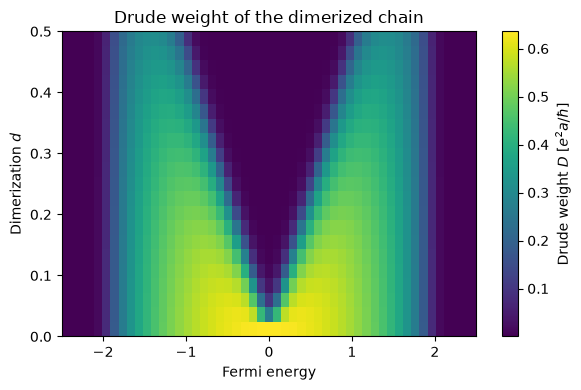

In [3]:
mus = np.linspace(-2.5,2.5,51) # Fermi energies
ds2 = np.linspace(0.,0.5,21) # dimerizations
Dmap = np.zeros((len(ds2),len(mus))) # storage
for i,d in enumerate(ds2):
    for j,mu in enumerate(mus):
        h = dimerized_chain(d)
        h.add_onsite(-mu) # states below mu are occupied
        Dmap[i,j] = h.get_drude_weight(nk=400,T=0.05)[0,0]

plt.figure(figsize=(6,4))
plt.imshow(Dmap,origin="lower",aspect="auto",cmap="viridis",
           extent=[mus[0],mus[-1],ds2[0],ds2[-1]])
plt.colorbar(label=r"Drude weight $D$ [$e^2 a/\hbar$]")
plt.xlabel("Fermi energy") ; plt.ylabel("Dimerization $d$")
plt.title("Drude weight of the dimerized chain")
plt.tight_layout()
plt.show()